In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="ticks")

In [2]:
raw_data_folder = '../data/raw'
processed_data_folder = '../data/processed'

df = pd.read_csv('../data/raw/deb_reach_birth_noise_1p000_kapnoise_20p0_seed_42.csv', )
df

,generator_species,point_id,z,v,kap,E_G,p_M,E_Hb,k_J,f,...,v_Hb,lb,tb,lb<f,k*vHb<c,reached_birth,success,execution_time,error_type,error_message
0,Abatus_cordatus,2,1.627626,0.029227,0.634395,3178.886358,7.113820,0.953882,0.000469,0.893773,...,0.000121,0.049254,0.030550,1,1,1,1,0.310322,none,NaN
1,Abatus_cordatus,3,1.467021,0.046912,0.840448,4460.966654,0.524611,0.799831,0.000071,0.744138,...,0.000299,0.066867,0.002114,1,1,1,1,0.296439,none,NaN
2,Abatus_cordatus,4,0.656400,0.028391,0.617245,3980.822385,26.582136,0.472227,0.002049,0.640953,...,0.000676,0.087165,0.068542,1,1,1,1,0.282601,none,NaN
3,Abatus_cordatus,5,0.188731,0.049116,0.792171,929.698995,17.106342,0.712798,0.001572,0.383723,...,0.434717,0.718562,0.329014,0,1,0,1,0.270790,none,NaN
4,Abatus_cordatus,6,0.635584,0.027986,0.799993,3412.514019,2.080371,0.579083,0.000454,0.737534,...,0.002644,0.138175,0.013759,1,1,1,1,0.240317,none,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
121295,NaN,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0,0,0,0,0.000000,NaN,NaN
121296,NaN,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0,0,0,0,0.000000,NaN,NaN
121297,NaN,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0,0,0,0,0.000000,NaN,NaN
121298,NaN,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0,0,0,0,0.000000,NaN,NaN


In [3]:
df['error_type'].value_counts()

error_type
none                  110304
par_gen_failed         10485
execution_error          177
time_limit_reached        19
Name: count, dtype: int64

In [4]:
col_types = {
    'parameter': df.columns[2:9].tolist(),
    'compound_parameter': df.columns[9:16].tolist(),
    'birth_simulation': df.columns[16:21].tolist(),
    'info': df.columns[0:2].tolist(),
    'log': df.columns[21:].tolist()
}
print(col_types)

{'parameter': ['z', 'v', 'kap', 'E_G', 'p_M', 'E_Hb', 'k_J'], 'compound_parameter': ['f', 'E_m', 'k_M', 'p_Am', 'g', 'k', 'v_Hb'], 'birth_simulation': ['lb', 'tb', 'lb<f', 'k*vHb<c', 'reached_birth'], 'info': ['generator_species', 'point_id'], 'log': ['success', 'execution_time', 'error_type', 'error_message']}


In [5]:
df['reached_birth'] = df['reached_birth'].astype(bool)
df['lb<f'] = df['lb<f'].astype(bool)
df['k*vHb<c'] = df['k*vHb<c'].astype(bool)

In [6]:
# Filter out rows with infinite values
df = df[df['execution_time'] > 0].copy()
# Filter out too small values for k*vHb
df = df[df['k'] * df['v_Hb'] > 1e-16].copy()
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=col_types['parameter'] + col_types['compound_parameter'])
df

,generator_species,point_id,z,v,kap,E_G,p_M,E_Hb,k_J,f,...,v_Hb,lb,tb,lb<f,k*vHb<c,reached_birth,success,execution_time,error_type,error_message
0,Abatus_cordatus,2,1.627626,0.029227,0.634395,3178.886358,7.113820,0.953882,0.000469,0.893773,...,0.000121,0.049254,0.030550,True,True,True,1,0.310322,none,NaN
1,Abatus_cordatus,3,1.467021,0.046912,0.840448,4460.966654,0.524611,0.799831,0.000071,0.744138,...,0.000299,0.066867,0.002114,True,True,True,1,0.296439,none,NaN
2,Abatus_cordatus,4,0.656400,0.028391,0.617245,3980.822385,26.582136,0.472227,0.002049,0.640953,...,0.000676,0.087165,0.068542,True,True,True,1,0.282601,none,NaN
3,Abatus_cordatus,5,0.188731,0.049116,0.792171,929.698995,17.106342,0.712798,0.001572,0.383723,...,0.434717,0.718562,0.329014,False,True,False,1,0.270790,none,NaN
4,Abatus_cordatus,6,0.635584,0.027986,0.799993,3412.514019,2.080371,0.579083,0.000454,0.737534,...,0.002644,0.138175,0.013759,True,True,True,1,0.240317,none,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120980,Zingel_asper,2,0.218121,0.038359,0.540632,7072.451976,108.864325,1.014537,0.002187,0.908286,...,0.016268,0.249554,0.115962,True,True,True,1,0.096085,none,NaN
120981,Zingel_asper,3,0.391232,0.004087,0.802238,9647.880260,170.228965,0.292807,0.001371,0.804655,...,0.002056,0.119730,0.709622,True,True,True,1,0.089119,none,NaN
120982,Zingel_asper,4,0.365982,0.028571,0.593984,6389.090955,143.413038,0.573752,0.000704,0.736108,...,0.002680,0.135850,0.176313,True,True,True,1,0.082802,none,NaN
120983,Zingel_asper,5,0.142177,0.035587,0.827976,2124.287754,32.666392,1.499591,0.003046,0.997414,...,1.182237,NaN,NaN,False,False,False,0,0.061395,none,NaN


<Axes: xlabel='v_Hb', ylabel='Count'>

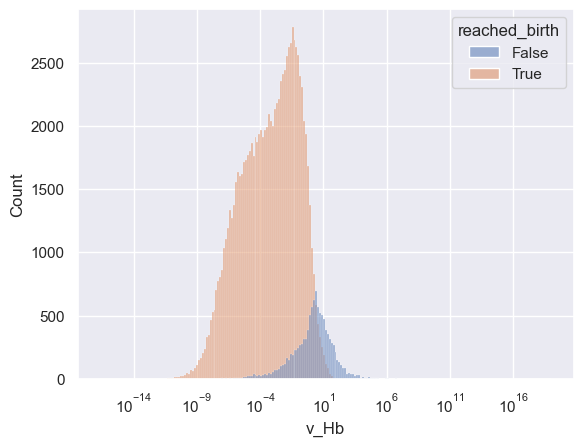

In [7]:
sns.histplot(data=df, x='v_Hb', hue='reached_birth', common_norm=False, log_scale=True )

<Axes: xlabel='k', ylabel='Count'>

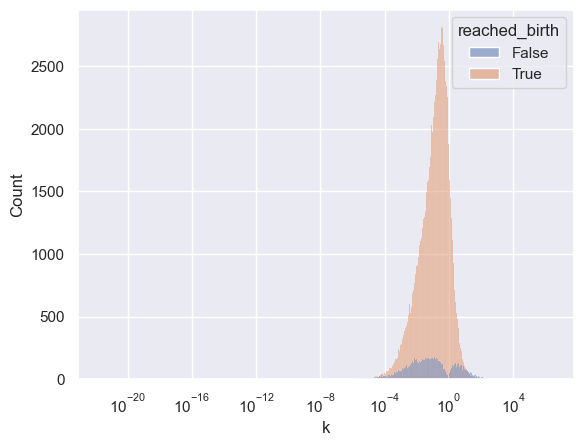

In [8]:
sns.histplot(data=df, x='k', hue='reached_birth', common_norm=False, log_scale=True )


<Axes: xlabel='g', ylabel='Count'>

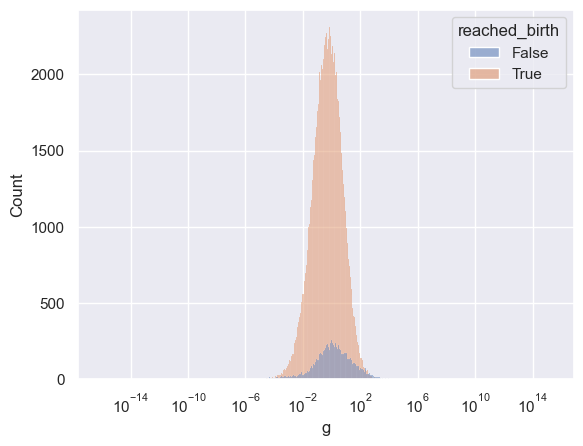

In [9]:
sns.histplot(data=df, x='g', hue='reached_birth', common_norm=False, log_scale=True )

<Axes: xlabel='None', ylabel='Count'>

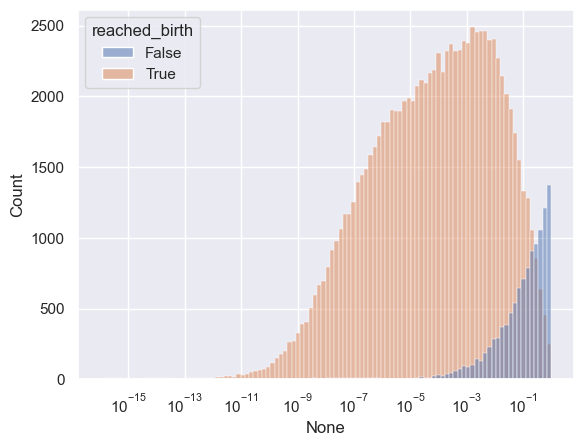

In [10]:
sns.histplot(x=df['k']*df['v_Hb'], hue=df['reached_birth'], common_norm=False, log_scale=True )


In [11]:
df['reached_birth'].mean()

np.float64(0.8961469322535544)

In [12]:
df[['lb<f', 'k*vHb<c']].value_counts()

lb<f   k*vHb<c
True   True       98707
False  False       5312
       True        3177
True   False       2950
Name: count, dtype: int64

In [13]:
df.groupby('generator_species')['reached_birth'].mean().sort_values()

generator_species
Dasyurus_viverrinus       0.000000
Isoodon_obesulus          0.000000
Succinea_putris           0.166667
Myotis_capaccinii         0.230769
Jenkinsia_lamprotaenia    0.250000
                            ...   
Micropterus_salmoides     1.000000
Abralia_trigonura         1.000000
Zebrasoma_flavescens      1.000000
Abbottina_rivularis       1.000000
Zebrasoma_scopas          1.000000
Name: reached_birth, Length: 6029, dtype: float64

In [14]:
df.groupby('generator_species').size().sort_values()

generator_species
Unio_pictorum              1
Etheostoma_perlongum       1
Mylochromis_anaphyrmus     1
Phoronis_psammophila       1
Schmidtea_polychroa        1
                          ..
Etelis_radiosus           20
Zebrasoma_flavescens      20
Abralia_trigonura         20
Abraliopsis_morisii       20
Zearaja_nasuta            20
Length: 6029, dtype: int64

## Split data and save

In [15]:
df.to_csv(f'{processed_data_folder}/deb_reach_birth.csv', index=False)

In [16]:
from src.debbirth.data.split import group_split_by_generator_species
data_split = group_split_by_generator_species(df)
data_split.train_df.to_csv(f'{processed_data_folder}/train.csv', index=False)
data_split.val_df.to_csv(f'{processed_data_folder}/val.csv', index=False)
data_split.test_df.to_csv(f'{processed_data_folder}/test.csv', index=False)